In [5]:
import laspy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
YS_DIR = Path("../data/real UAV")
all_files = sorted(YS_DIR.glob("*.laz"))
print(f"real UAV: {len(all_files)} files")
for f in all_files:
    print(f"  {f.name}")

real UAV: 1 files
  VA50-SC20-M600-120mAGL-10ms-SACOCU-Pipeline_survey(1).laz


In [ ]:
f = all_files[0]
las = laspy.read(str(f))
print(f"\n=== {f.name} ===")
print(f"Points: {len(las.points):,}")
for dim in las.point_format.dimension_names:
    arr = np.array(getattr(las, dim), dtype=np.float64)
    print(f"  {dim:<25} min={arr.min():>14.3f}  max={arr.max():>14.3f}  mean={arr.mean():>14.3f}")


=== VA50-SC20-M600-120mAGL-10ms-SACOCU-Pipeline_survey(1).laz ===
Points: 227,938,937
  X                         min=   -754429.000  max=    132874.000  mean=   -329291.994
  Y                         min=   -964405.000  max=    123684.000  mean=   -444374.247
  Z                         min=    -50164.000  max=     39631.000  mean=     -3655.985
  intensity                 min=     31637.000  max=     65535.000  mean=     58783.899
  return_number             min=         1.000  max=         6.000  mean=         1.083
  number_of_returns         min=         1.000  max=         6.000  mean=         1.170
  scan_direction_flag       min=         0.000  max=         0.000  mean=         0.000
  edge_of_flight_line       min=         0.000  max=         0.000  mean=         0.000
  classification            min=         0.000  max=         0.000  mean=         0.000
  synthetic                 min=         0.000  max=         0.000  mean=         0.000
  key_point                 min= 

In [ ]:
# Κατανομή κλάσεων
CLASS_NAMES = {
    0: "Never Classified", 1: "Unclassified", 2: "Ground",
    3: "Low Vegetation", 4: "Medium Vegetation", 5: "High Vegetation",
    6: "Building", 9: "Water", 17: "Bridge", 64: "Perennial Snow"
}

total_counts = {}
for f in all_files:
    las = laspy.read(str(f))
    cls, cnt = np.unique(np.array(las.classification), return_counts=True)
    for c, n in zip(cls, cnt):
        total_counts[int(c)] = total_counts.get(int(c), 0) + int(n)

total = sum(total_counts.values())
print(f"=== real UAV ({total:,} points) ===")
print(f"  {'Κλάση':<5} {'Όνομα':<20} {'Πλήθος':>14} {'%':>8}")
print(f"  {'-'*52}")
for c, n in sorted(total_counts.items()):
    name = CLASS_NAMES.get(c, f"cls_{c}")
    print(f"  {c:<5} {name:<20} {n:>14,} {100*n/total:>7.1f}%")

=== real UAV (227,938,937 points) ===
  Κλάση Όνομα                        Πλήθος        %
  ----------------------------------------------------
  0     Never Classified        227,938,937   100.0%


In [ ]:
# Άχρηστες στήλες
DROP_DIMS = [
    "synthetic", "key_point", "withheld",
    "scan_direction_flag", "edge_of_flight_line",
    "user_data", "gps_time", "point_source_id"
]

las = laspy.read(str(all_files[0]))
KEEP_DIMS = [dim for dim in las.point_format.dimension_names if dim not in DROP_DIMS]

print("Πετάμε:")
for d in DROP_DIMS:
    print(f"  - {d}")
print(f"\nΚρατάμε:")
for d in KEEP_DIMS:
    print(f"  - {d}")

Πετάμε:
  - synthetic
  - key_point
  - withheld
  - scan_direction_flag
  - edge_of_flight_line
  - user_data
  - gps_time
  - point_source_id

Κρατάμε:
  - X
  - Y
  - Z
  - intensity
  - return_number
  - number_of_returns
  - classification
  - scan_angle_rank
  - red
  - green
  - blue
  - ExtraBytes


In [ ]:
# Corrupt points και RGB zeros
las = laspy.read(str(all_files[0]))
total = len(las.points)

rn = np.array(las.return_number)
nr = np.array(las.number_of_returns)
r  = np.array(las.red)
g  = np.array(las.green)
b  = np.array(las.blue)

corrupt  = int(((rn == 0) | (nr == 0)).sum())
rgb_zero = int(((r == 0) & (g == 0) & (b == 0)).sum())

print(f"real UAV ({total:,} pts)")
print(f"  Corrupt (return=0):  {corrupt:>12,}  ({100*corrupt/total:.3f}%)")
print(f"  RGB ολικό μηδέν:     {rgb_zero:>12,}  ({100*rgb_zero/total:.3f}%)")

real UAV (227,938,937 pts)
  Corrupt (return=0):             0  (0.000%)
  RGB ολικό μηδέν:                1  (0.000%)


In [ ]:
# Σύγκριση RGB scales
las_ys = laspy.read(str(all_files[0]))
las_fr = laspy.read(str(sorted(Path("../data/train/00").glob("*.laz"))[0]))

for ch in ["red", "green", "blue"]:
    fr = np.array(getattr(las_fr, ch))
    ys = np.array(getattr(las_ys, ch))
    print(f"{ch}:")
    print(f"  FRACTAL:    min={fr.min()}, max={fr.max()}, mean={fr.mean():.0f}")
    print(f"  YellowScan: min={ys.min()}, max={ys.max()}, mean={ys.mean():.0f}")

# ExtraBytes — τι είναι;
eb = np.array(las_ys['ExtraBytes'])
print(f"\nExtraBytes: min={eb.min()}, max={eb.max()}, mean={eb.mean():.1f}, unique={len(np.unique(eb))}")

red:
  FRACTAL:    min=0, max=64256, mean=23968
  YellowScan: min=0, max=65535, mean=32241
green:
  FRACTAL:    min=0, max=64000, mean=24362
  YellowScan: min=0, max=65535, mean=28467
blue:
  FRACTAL:    min=0, max=62464, mean=23342
  YellowScan: min=0, max=65535, mean=24960

ExtraBytes: min=65, max=240, mean=152.5, unique=2


In [1]:
FEATURE_DIMS = ["x", "y", "z", "intensity", "return_number", 
                "number_of_returns", "scan_angle_rank"]

print("Τελικά features:")
for f in FEATURE_DIMS:
    print(f"  - {f}")
print(f"\nΣύνολο: {len(FEATURE_DIMS)} features")

Τελικά features:
  - x
  - y
  - z
  - intensity
  - return_number
  - number_of_returns
  - scan_angle_rank

Σύνολο: 7 features


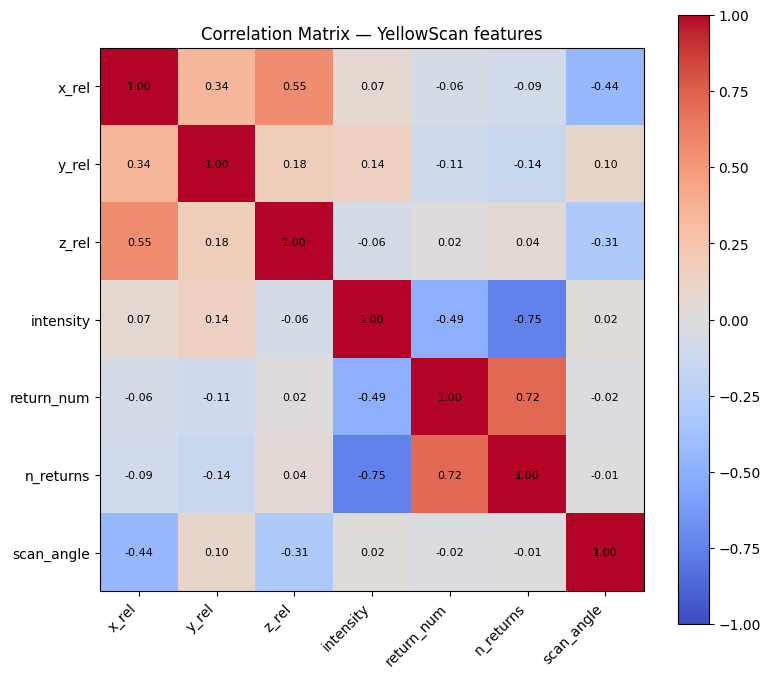

In [8]:
las = laspy.read(str(all_files[0]))

x = np.array(las.x); yc = np.array(las.y); z = np.array(las.z)

X_ys = np.column_stack([
    x - x.mean(), yc - yc.mean(), z - z.mean(),
    np.array(las.intensity),
    np.array(las.return_number),
    np.array(las.number_of_returns),
    np.array(las.scan_angle_rank),
])

NAMES_YS = ["x_rel", "y_rel", "z_rel", "intensity", "return_num", "n_returns", "scan_angle"]

idx = np.random.choice(len(X_ys), 10000, replace=False)
X_ys_s = X_ys[idx]

# Correlation matrix
corr = np.corrcoef(X_ys_s.T)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(NAMES_YS))); ax.set_xticklabels(NAMES_YS, rotation=45, ha="right")
ax.set_yticks(range(len(NAMES_YS))); ax.set_yticklabels(NAMES_YS)
for i in range(len(NAMES_YS)):
    for j in range(len(NAMES_YS)):
        ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation Matrix — YellowScan features")
plt.tight_layout()
plt.show()

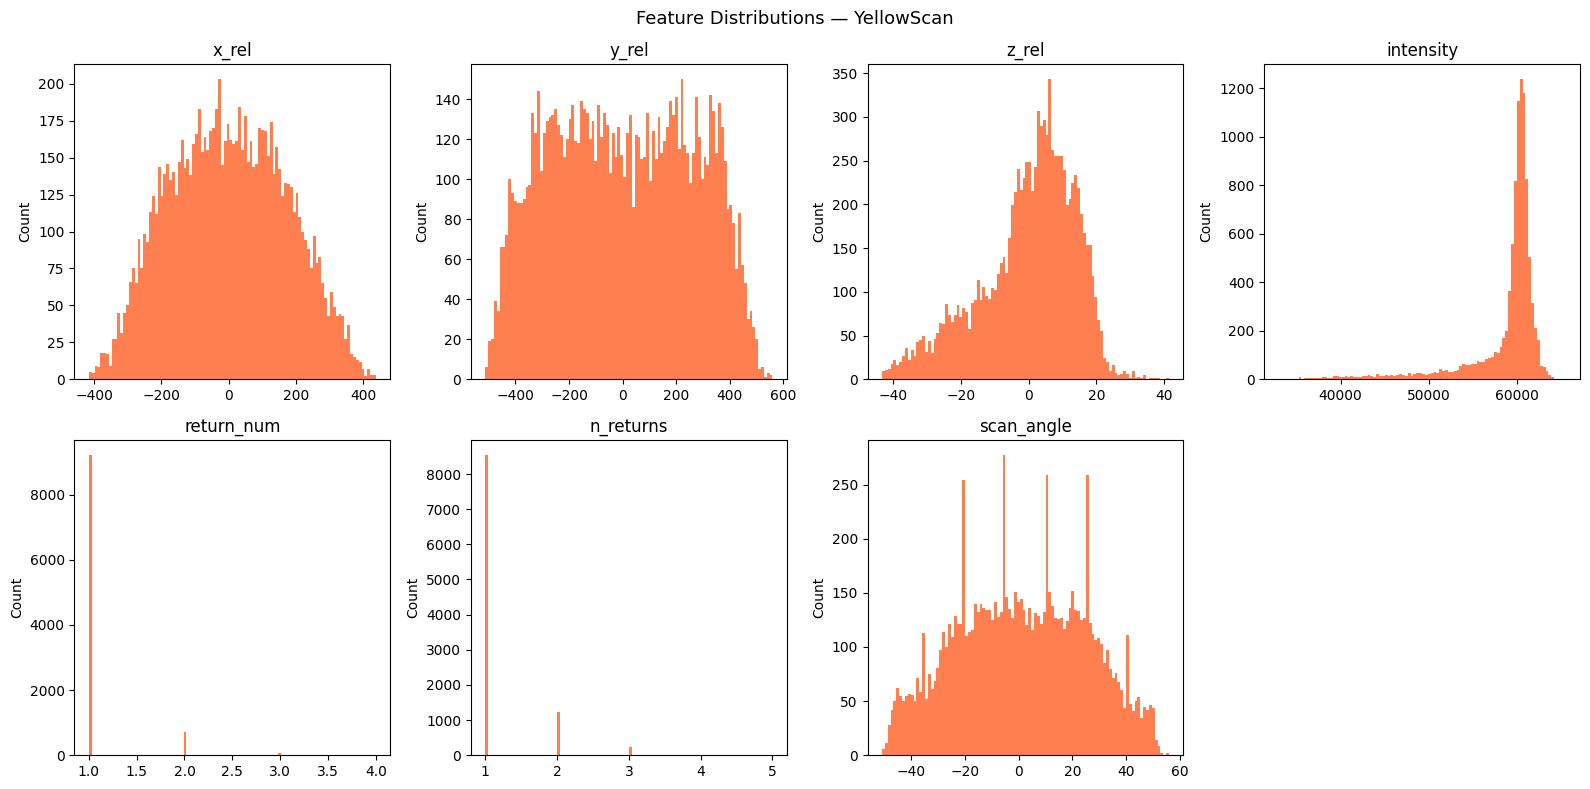

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, name in enumerate(NAMES_YS):
    axes[i].hist(X_ys_s[:, i], bins=100, color="coral", edgecolor="none")
    axes[i].set_title(name)
    axes[i].set_ylabel("Count")

axes[-1].axis("off")
plt.suptitle("Feature Distributions — YellowScan", fontsize=13)
plt.tight_layout()
plt.show()

Το intensity saturation είναι πρόβλημα. Το YellowScan έχει χιλιάδες points στο max (65535) — σημαίνει saturated sensor. Το StandardScaler θα το χειριστεί, αλλά αξίζει να το σημειώσουμε.

In [10]:
from sklearn.preprocessing import StandardScaler
import json

las = laspy.read(str(all_files[0]))

x = np.array(las.x); yc = np.array(las.y); z = np.array(las.z)

scaler_x   = StandardScaler().fit((x  - x.mean()).reshape(-1, 1))
scaler_y   = StandardScaler().fit((yc - yc.mean()).reshape(-1, 1))
scaler_z   = StandardScaler().fit((z  - z.mean()).reshape(-1, 1))
scaler_int = StandardScaler().fit(np.array(las.intensity).reshape(-1, 1))

stats_ys = {
    "x_rel":     {"mean": float(scaler_x.mean_[0]),   "std": float(scaler_x.scale_[0])},
    "y_rel":     {"mean": float(scaler_y.mean_[0]),   "std": float(scaler_y.scale_[0])},
    "z_rel":     {"mean": float(scaler_z.mean_[0]),   "std": float(scaler_z.scale_[0])},
    "intensity": {"mean": float(scaler_int.mean_[0]), "std": float(scaler_int.scale_[0])},
}

with open("../outputs/normalizer_stats_yellowscan.json", "w") as f:
    json.dump(stats_ys, f, indent=2)

print("YellowScan stats:")
for feat, s in stats_ys.items():
    print(f"  {feat:<12} mean={s['mean']:>12.3f}  std={s['std']:>10.3f}")

YellowScan stats:
  x_rel        mean=       0.000  std=   170.157
  y_rel        mean=      -0.000  std=   259.334
  z_rel        mean=      -0.000  std=    13.992
  intensity    mean=   58783.899  std=  4381.196


το Intensity είναι ξεκάθαρα δείγμα OOD που θέλουμε 

In [12]:
import json

with open("../outputs/normalizer_stats.json") as f:
    stats = json.load(f)

def normalize(x_rel, y_rel, z_rel, intensity, return_num, n_returns, scan_angle, is_fractal=True):
    out = np.zeros((len(x_rel), 7), dtype=np.float32)
    out[:, 0] = (x_rel     - stats["x_rel"]["mean"])     / stats["x_rel"]["std"]
    out[:, 1] = (y_rel     - stats["y_rel"]["mean"])     / stats["y_rel"]["std"]
    out[:, 2] = (z_rel     - stats["z_rel"]["mean"])     / stats["z_rel"]["std"]
    out[:, 3] = (intensity - stats["intensity"]["mean"]) / stats["intensity"]["std"]
    out[:, 4] = return_num / 6.0
    out[:, 5] = n_returns  / 6.0
    if is_fractal:
        out[:, 6] = scan_angle * 0.006 / 60.0
    else:
        out[:, 6] = scan_angle / 60.0
    return out

NAMES = ["x_rel", "y_rel", "z_rel", "intensity", "return_num", "n_returns", "scan_angle"]

In [13]:
las_ys = laspy.read(str(all_files[0]))
x = np.array(las_ys.x); yc = np.array(las_ys.y); z = np.array(las_ys.z)

X_ys_norm = normalize(
    x - x.mean(), yc - yc.mean(), z - z.mean(),
    np.array(las_ys.intensity),
    np.array(las_ys.return_number),
    np.array(las_ys.number_of_returns),
    np.array(las_ys.scan_angle_rank),
    is_fractal=False
)

print(f"{'Feature':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 44)
for i, name in enumerate(NAMES):
    print(f"{name:<12} {X_ys_norm[:,i].mean():>8.3f} {X_ys_norm[:,i].std():>8.3f} {X_ys_norm[:,i].min():>8.3f} {X_ys_norm[:,i].max():>8.3f}")

Feature          Mean      Std      Min      Max
--------------------------------------------
x_rel           0.000   11.831  -29.560   32.135
y_rel           0.000   18.047  -36.189   39.531
z_rel          -0.000    2.094   -6.961    6.479
intensity       3.601    0.307    1.701    4.074
return_num      0.181    0.051    0.167    1.000
n_returns       0.195    0.073    0.167    1.000
scan_angle      0.018    0.401   -0.917    1.000
